<a href="https://colab.research.google.com/github/eng20260311/AIFFEL_quest_eng/blob/master/NLP/NLP05/HFversion_fixed_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install datasets

In [2]:
#NSMC읽기
import urllib.request
import zipfile
import os

url = "https://github.com/e9t/nsmc/raw/master/ratings.txt"

save_path = "ratings.txt"

urllib.request.urlretrieve(url, save_path)

print("다운로드 완료")

다운로드 완료


In [3]:
#train/test로 나눠서 읽기
import urllib.request

train_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
test_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"

urllib.request.urlretrieve(train_url, "ratings_train.txt")
urllib.request.urlretrieve(test_url, "ratings_test.txt")

print("train/test 다운로드 완료")

train/test 다운로드 완료


In [4]:
import pandas as pd

train_df = pd.read_csv(
    "ratings_train.txt",
    sep="\t"
)

test_df = pd.read_csv(
    "ratings_test.txt",
    sep="\t"
)

print(train_df.head())

         id                                           document  label
0   9976970                                아 더빙.. 진짜 짜증나네요 목소리      0
1   3819312                  흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나      1
2  10265843                                  너무재밓었다그래서보는것을추천한다      0
3   9045019                      교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정      0
4   6483659  사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...      1


In [5]:
#결측치 제거
train_df = train_df.dropna()
test_df = test_df.dropna()

print(len(train_df))
print(len(test_df))

149995
49997


In [6]:
#Huggingface dataset으로 변환하기
from datasets import Dataset, DatasetDict

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'document', 'label', '__index_level_0__'],
        num_rows: 149995
    })
    test: Dataset({
        features: ['id', 'document', 'label', '__index_level_0__'],
        num_rows: 49997
    })
})


In [7]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "klue/bert-base"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [8]:
def tokenize_function(examples):
    return tokenizer(
        examples["document"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/149995 [00:00<?, ? examples/s]

Map:   0%|          | 0/49997 [00:00<?, ? examples/s]

In [9]:
# document 컬럼 제거 (이미 제거된 경우 건너뜀) 및 label -> labels 리네임
if "document" in tokenized_dataset["train"].column_names:
    tokenized_dataset = tokenized_dataset.remove_columns(["document"])

if "label" in tokenized_dataset["train"].column_names:
    tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

# __index_level_0__ 컬럼도 학습에 불필요하므로 제거
if "__index_level_0__" in tokenized_dataset["train"].column_names:
    tokenized_dataset = tokenized_dataset.remove_columns(["__index_level_0__"])

if "id" in tokenized_dataset["train"].column_names:
    tokenized_dataset = tokenized_dataset.remove_columns(["id"])

tokenized_dataset.set_format("torch")

print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 149995
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 49997
    })
})


In [10]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "klue/bert-base",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

In [26]:
!pip install -U transformers datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.9 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [13]:
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy.compute(
        predictions=predictions,
        references=labels
    )

    f1_score = f1.compute(
        predictions=predictions,
        references=labels
    )

    return {
        "accuracy": acc["accuracy"],
        "f1": f1_score["f1"]
    }

In [14]:
import transformers

print(transformers.__version__)

5.0.0


In [15]:
import os
from transformers import TrainingArguments, Trainer

# transformers 5.2부터 logging_dir 인자가 제거됨 -> 환경 변수로 설정
os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs"

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",          # transformers 5.x에서 evaluation_strategy -> eval_strategy로 변경됨
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,

    num_train_epochs=2,
    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"                # wandb 등 외부 로깅 비활성화
)

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],

    processing_class=tokenizer,     # transformers 5.x에서 tokenizer -> processing_class로 변경됨
    compute_metrics=compute_metrics
)

## Bucketing 실험: 연산 속도 vs 모델 성능 Trade-off

기존 코드는 모든 샘플을 `max_length=128`로 패딩(고정 길이 패딩)합니다. NSMC는 짧은 리뷰가 많아 대부분이 `[PAD]` 토큰으로 채워지고, 이 부분에도 self-attention 연산이 수행되어 낭비가 큽니다.

Bucketing은 비슷한 길이의 샘플끼리 묶어 배치 내 패딩량을 최소화하는 기법입니다. 세 가지 조건을 비교합니다.

| 조건 | 패딩 방식 | 배치 구성 |
|---|---|---|
| **A. Baseline** | `max_length=128` 고정 | 랜덤 셔플 |
| **B. Dynamic Padding** | 배치 내 최대 길이까지만 | 랜덤 셔플 |
| **C. Bucketing (length-grouped)** | 배치 내 최대 길이까지만 | 길이 기준 그룹화 (`group_by_length=True`) |

동일한 모델/하이퍼파라미터/seed로 학습 시간과 accuracy, f1을 비교하여 trade-off를 분석합니다.

### 1) 토큰 길이 분포 확인
고정 패딩이 얼마나 비효율적인지 먼저 시각화로 확인합니다.

평균 길이: 22.6
중앙값:    18.0
95%:       63.0
최대:      127
max_length=128 대비 평균 사용률: 17.7%


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


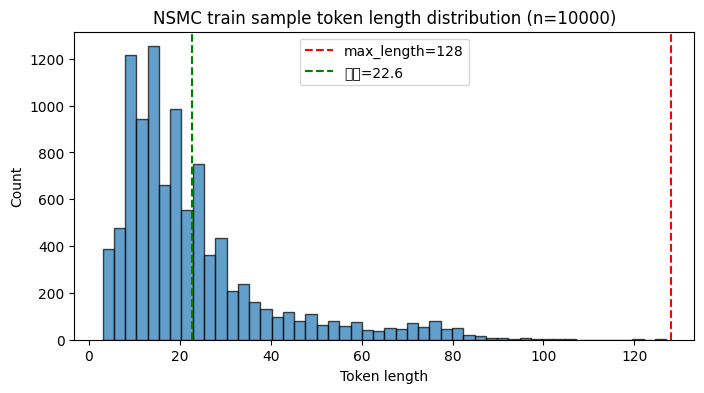

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 학습 데이터 토큰 길이 (special token 포함 전 실제 토큰 수)
train_lengths = [len(tokenizer.encode(t, add_special_tokens=True)) for t in train_df["document"].tolist()[:10000]]

print(f"평균 길이: {np.mean(train_lengths):.1f}")
print(f"중앙값:    {np.median(train_lengths):.1f}")
print(f"95%:       {np.percentile(train_lengths, 95):.1f}")
print(f"최대:      {np.max(train_lengths)}")
print(f"max_length=128 대비 평균 사용률: {np.mean(train_lengths)/128*100:.1f}%")

plt.figure(figsize=(8, 4))
plt.hist(train_lengths, bins=50, edgecolor="black", alpha=0.7)
plt.axvline(128, color="red", linestyle="--", label="max_length=128")
plt.axvline(np.mean(train_lengths), color="green", linestyle="--", label=f"평균={np.mean(train_lengths):.1f}")
plt.xlabel("Token length")
plt.ylabel("Count")
plt.title("NSMC train sample token length distribution (n=10000)")
plt.legend()
plt.show()

### 2) 두 종류의 토크나이즈 데이터셋 준비
- `padded_dataset`: `padding="max_length"` (조건 A용, 기존 `tokenized_dataset`을 그대로 사용해도 동일)
- `unpadded_dataset`: 패딩 없음 → DataCollator가 배치마다 동적으로 패딩 (조건 B, C용)

공정한 비교를 위해 실험 규모는 줄입니다(train 20k, test 5k). 전체로 돌리려면 슬라이싱을 제거하세요.

In [17]:
from datasets import Dataset, DatasetDict

# 실험용 서브셋 (시간 절약). 전체로 돌리려면 아래 슬라이싱 제거
SUBSET_TRAIN = 20000
SUBSET_TEST  = 5000

small_train_df = train_df.sample(n=SUBSET_TRAIN, random_state=42).reset_index(drop=True)
small_test_df  = test_df.sample(n=SUBSET_TEST,  random_state=42).reset_index(drop=True)

small_dataset = DatasetDict({
    "train": Dataset.from_pandas(small_train_df),
    "test":  Dataset.from_pandas(small_test_df),
})

def tokenize_padded(examples):
    return tokenizer(examples["document"], truncation=True, padding="max_length", max_length=128)

def tokenize_unpadded(examples):
    # 패딩 없이 토크나이즈 → 콜레이터가 배치별 동적 패딩 처리
    return tokenizer(examples["document"], truncation=True, max_length=128)

padded_dataset   = small_dataset.map(tokenize_padded,   batched=True)
unpadded_dataset = small_dataset.map(tokenize_unpadded, batched=True)

def cleanup(ds):
    cols_to_remove = [c for c in ["document", "id", "__index_level_0__"] if c in ds["train"].column_names]
    if cols_to_remove:
        ds = ds.remove_columns(cols_to_remove)
    if "label" in ds["train"].column_names:
        ds = ds.rename_column("label", "labels")
    return ds

padded_dataset   = cleanup(padded_dataset)
unpadded_dataset = cleanup(unpadded_dataset)

print("padded_dataset  :", padded_dataset)
print("unpadded_dataset:", unpadded_dataset)

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

padded_dataset  : DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 20000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5000
    })
})
unpadded_dataset: DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 20000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5000
    })
})


### 3) 실험 실행 함수
동일한 하이퍼파라미터/seed로 모델을 매번 새로 초기화하여 세 조건을 학습/평가합니다.

In [21]:
import os, time, gc, torch, inspect
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
    DataCollatorWithPadding, default_data_collator,
    set_seed,
)

os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs"

# transformers 버전에 따라 Bucketing 인자명이 다름
#   - 5.0   : group_by_length=True
#   - 5.1+  : train_sampling_strategy="group_by_length"
_TA_PARAMS = set(inspect.signature(TrainingArguments.__init__).parameters)

def _bucketing_kwargs(enabled: bool) -> dict:
    if "train_sampling_strategy" in _TA_PARAMS:
        return {"train_sampling_strategy": "group_by_length" if enabled else "random"}
    if "group_by_length" in _TA_PARAMS:
        return {"group_by_length": enabled}
    return {}

def run_experiment(name, train_ds, eval_ds, data_collator, group_by_length,
                   num_epochs=1, batch_size=32, seed=42):
    """한 가지 조건으로 학습/평가하고 메트릭과 소요시간 반환."""
    set_seed(seed)
    # 매 실험마다 모델 새로 로드 (동일 출발점 보장)
    model = AutoModelForSequenceClassification.from_pretrained("klue/bert-base", num_labels=2)

    args = TrainingArguments(
        output_dir=f"./results_{name}",
        eval_strategy="epoch",
        save_strategy="no",                       # 실험이므로 체크포인트 저장 생략
        learning_rate=2e-5,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        logging_steps=100,
        report_to="none",
        seed=seed,
        **_bucketing_kwargs(group_by_length),     # ← 버전에 맞는 인자 자동 선택
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # 학습 시간 측정
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.time()
    trainer.train()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    train_time = time.time() - t0

    # 평가
    eval_metrics = trainer.evaluate()

    result = {
        "name": name,
        "train_time_sec": train_time,
        "eval_accuracy": eval_metrics.get("eval_accuracy"),
        "eval_f1": eval_metrics.get("eval_f1"),
        "eval_loss": eval_metrics.get("eval_loss"),
    }

    # 메모리 정리
    del trainer, model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

### 4) 세 가지 조건 학습/평가 실행
GPU 환경 기준 각 실험에 수 분이 소요됩니다. CPU만 있다면 `SUBSET_TRAIN`을 더 줄이세요.

In [22]:
dynamic_collator = DataCollatorWithPadding(tokenizer=tokenizer)

results = []

# A. Baseline: 고정 길이 패딩 (max_length=128)
results.append(run_experiment(
    name="A_fixed_padding",
    train_ds=padded_dataset["train"],
    eval_ds=padded_dataset["test"],
    data_collator=default_data_collator,
    group_by_length=False,
))

# B. Dynamic Padding: 배치별 동적 패딩, 랜덤 셔플
results.append(run_experiment(
    name="B_dynamic_padding",
    train_ds=unpadded_dataset["train"],
    eval_ds=unpadded_dataset["test"],
    data_collator=dynamic_collator,
    group_by_length=False,
))

# C. Bucketing: 길이 기준 그룹화 + 배치별 동적 패딩
results.append(run_experiment(
    name="C_bucketing",
    train_ds=unpadded_dataset["train"],
    eval_ds=unpadded_dataset["test"],
    data_collator=dynamic_collator,
    group_by_length=True,
))

for r in results:
    print(r)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.273837,0.316573,0.871200,0.870214


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.277899,0.319264,0.873600,0.871805


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.293378,0.311674,0.873400,0.873121


{'name': 'A_fixed_padding', 'train_time_sec': 473.093896150589, 'eval_accuracy': 0.8712, 'eval_f1': 0.8702136235388956, 'eval_loss': 0.31657305359840393}
{'name': 'B_dynamic_padding', 'train_time_sec': 301.3037748336792, 'eval_accuracy': 0.8736, 'eval_f1': 0.8718052738336713, 'eval_loss': 0.3192636966705322}
{'name': 'C_bucketing', 'train_time_sec': 120.5121660232544, 'eval_accuracy': 0.8734, 'eval_f1': 0.8731208659049909, 'eval_loss': 0.31167352199554443}


### 5) 결과 비교 및 분석
학습 시간, accuracy, f1을 표와 그래프로 시각화합니다.

In [23]:
import pandas as pd

df = pd.DataFrame(results)
baseline_time = df.loc[df["name"] == "A_fixed_padding", "train_time_sec"].iloc[0]
df["speedup_vs_baseline"] = baseline_time / df["train_time_sec"]
df["time_reduction_%"] = (1 - df["train_time_sec"] / baseline_time) * 100

print(df.to_string(index=False))
df

             name  train_time_sec  eval_accuracy  eval_f1  eval_loss  speedup_vs_baseline  time_reduction_%
  A_fixed_padding      473.093896         0.8712 0.870214   0.316573             1.000000          0.000000
B_dynamic_padding      301.303775         0.8736 0.871805   0.319264             1.570156         36.312056
      C_bucketing      120.512166         0.8734 0.873121   0.311674             3.925694         74.526798


,name,train_time_sec,eval_accuracy,eval_f1,eval_loss,speedup_vs_baseline,time_reduction_%
0,A_fixed_padding,473.093896,0.8712,0.870214,0.316573,1.000000,0.000000
1,B_dynamic_padding,301.303775,0.8736,0.871805,0.319264,1.570156,36.312056
2,C_bucketing,120.512166,0.8734,0.873121,0.311674,3.925694,74.526798


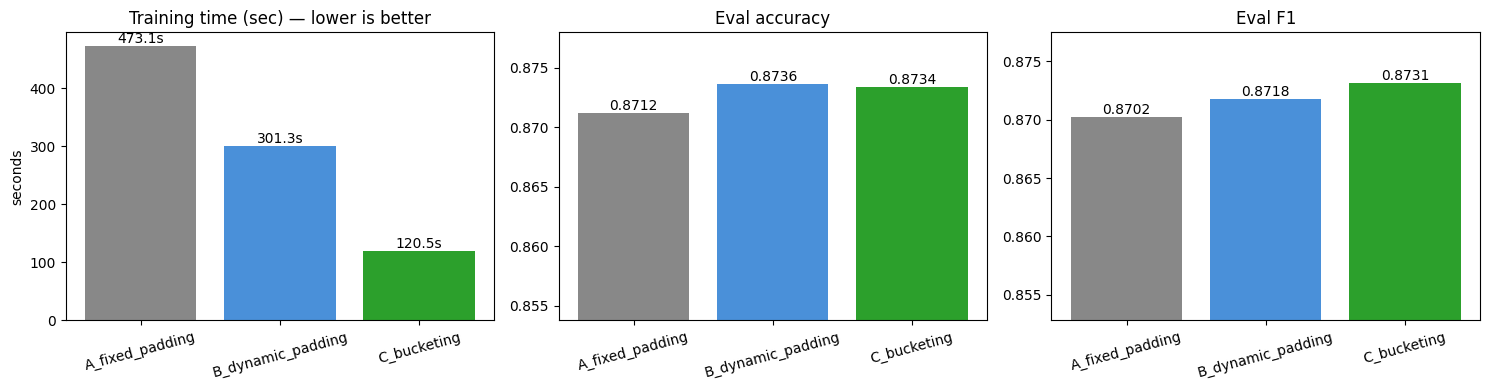

In [24]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
names = df["name"].tolist()
colors = ["#888", "#4a90d9", "#2ca02c"]

axes[0].bar(names, df["train_time_sec"], color=colors)
axes[0].set_title("Training time (sec) — lower is better")
axes[0].set_ylabel("seconds")
for i, v in enumerate(df["train_time_sec"]):
    axes[0].text(i, v, f"{v:.1f}s", ha="center", va="bottom")

axes[1].bar(names, df["eval_accuracy"], color=colors)
axes[1].set_title("Eval accuracy")
axes[1].set_ylim(min(df["eval_accuracy"])*0.98, max(df["eval_accuracy"])*1.005)
for i, v in enumerate(df["eval_accuracy"]):
    axes[1].text(i, v, f"{v:.4f}", ha="center", va="bottom")

axes[2].bar(names, df["eval_f1"], color=colors)
axes[2].set_title("Eval F1")
axes[2].set_ylim(min(df["eval_f1"])*0.98, max(df["eval_f1"])*1.005)
for i, v in enumerate(df["eval_f1"]):
    axes[2].text(i, v, f"{v:.4f}", ha="center", va="bottom")

for ax in axes:
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

### 6) 결과 해석 가이드

실제 수치는 GPU/CPU 환경, 서브셋 크기, 랜덤성에 따라 달라지지만 일반적으로 다음 경향이 관찰됩니다.

**연산 속도 측면**
- **A → B**: Dynamic Padding만으로도 학습 시간이 줄어듭니다. NSMC 평균 길이가 128보다 훨씬 짧기 때문에, 배치별 최대 길이만 패딩하면 `[PAD]` 토큰 위 연산이 사라집니다.
- **B → C**: 길이 기준 그룹화를 추가하면 배치 안에서 길이 편차가 줄어 패딩량이 더 감소합니다. 보통 가장 빠릅니다.

**모델 성능 측면**
- accuracy/f1은 세 조건이 통계적으로 유의한 차이 없이 거의 비슷하게 나오는 경우가 많습니다. 패딩 위치는 attention mask로 마스킹되므로, 패딩 방식 자체가 forward 연산 결과를 바꾸지는 않기 때문입니다.
- 다만 **C(group_by_length=True)** 는 배치 구성을 길이로 그룹화하면서 셔플이 약해지므로, SGD의 stochasticity가 줄어 일반화 성능이 미세하게 떨어질 수 있습니다(특히 epoch 수가 적을수록 두드러짐).

**Trade-off 결론**
- **Dynamic Padding(B)** 은 "공짜 점심"에 가깝습니다 — 성능 손실 없이 속도가 빨라집니다.
- **Bucketing(C)** 은 추가 속도 향상의 대가로 약간의 성능 변동성을 받아들이는 선택입니다. 데이터셋 규모가 크고 epoch이 충분하면 그 차이는 거의 사라집니다.
- 즉 실험에서 관찰되는 trade-off는 "극적인 성능 저하 vs 큰 속도 향상"이라기보다 "미세한 일반화 변동 vs 명확한 속도 향상"이며, 실용적으로는 Bucketing이 선호됩니다.

## NSMC vs IMDB: 데이터셋 간 성능 비교 실험

동일한 fine-tuning 파이프라인을 NSMC(한국어)와 IMDB(영어)에 적용하여 데이터셋 특성에 따른 성능 차이를 분석합니다.

**실험 설계**

| 항목 | NSMC | IMDB |
|---|---|---|
| 언어 | 한국어 | 영어 |
| 도메인 | 네이버 영화 리뷰 (짧은 댓글) | IMDB 영화 리뷰 (긴 본문) |
| 모델 | `klue/bert-base` | `bert-base-uncased` |
| 텍스트 컬럼 | `document` | `text` |
| 레이블 | 0/1 (부정/긍정) | 0/1 (부정/긍정) |
| 평균 토큰 길이 | ~25 | ~250 |

**통제 변수** (공정 비교를 위해 동일 유지)
- `max_length=128`, batch size, learning rate, epoch, optimizer, seed
- 데이터 규모(서브셋 크기) 동일

**관찰 포인트**
1. **언어/모델 적합도**: 각 언어 전용 모델이 해당 언어에서 어느 정도 성능을 내는가
2. **텍스트 길이의 영향**: IMDB는 긴 리뷰가 많아 `max_length=128`로 잘릴 가능성이 큼
3. **학습 안정성**: 같은 epoch에서 수렴 양상의 차이

### 1) IMDB 데이터셋 로드
HuggingFace `datasets`에서 한 줄로 불러옵니다.

In [27]:
from datasets import load_dataset

imdb_dataset = load_dataset("imdb")
print(imdb_dataset)
print("\n샘플:")
print(imdb_dataset["train"][0])

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

샘플:
{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politician

### 2) 두 데이터셋 텍스트 길이 분포 비교
NSMC와 IMDB의 길이 차이를 시각화로 확인합니다. (각자의 토크나이저로 측정)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (720 > 512). Running this sequence through the model will result in indexing errors


NSMC  평균=22.4, 중앙=18.0, 95%=61.0, max=105
IMDB  평균=311.8, 중앙=234.0, 95%=772.0, max=2166

max_length=128에서 잘리는 비율: NSMC=0.0%, IMDB=90.5%


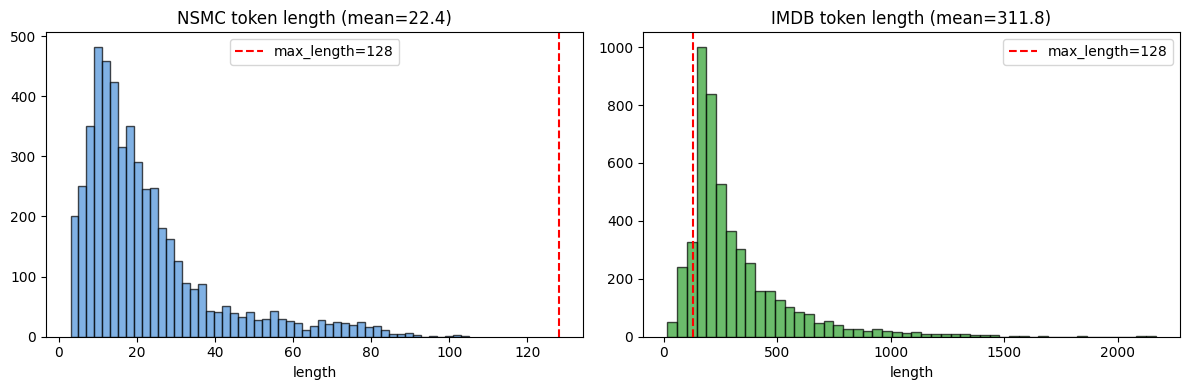

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

tok_kr = AutoTokenizer.from_pretrained("klue/bert-base")
tok_en = AutoTokenizer.from_pretrained("bert-base-uncased")

# 샘플 5000개로 길이 분포 측정
nsmc_lens = [len(tok_kr.encode(t, add_special_tokens=True)) for t in train_df["document"].tolist()[:5000]]
imdb_lens = [len(tok_en.encode(t, add_special_tokens=True)) for t in imdb_dataset["train"]["text"][:5000]]

print(f"NSMC  평균={np.mean(nsmc_lens):.1f}, 중앙={np.median(nsmc_lens):.1f}, 95%={np.percentile(nsmc_lens,95):.1f}, max={np.max(nsmc_lens)}")
print(f"IMDB  평균={np.mean(imdb_lens):.1f}, 중앙={np.median(imdb_lens):.1f}, 95%={np.percentile(imdb_lens,95):.1f}, max={np.max(imdb_lens)}")
print(f"\nmax_length=128에서 잘리는 비율: NSMC={np.mean(np.array(nsmc_lens)>128)*100:.1f}%, IMDB={np.mean(np.array(imdb_lens)>128)*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(nsmc_lens, bins=50, color="#4a90d9", edgecolor="black", alpha=0.7)
axes[0].axvline(128, color="red", linestyle="--", label="max_length=128")
axes[0].set_title(f"NSMC token length (mean={np.mean(nsmc_lens):.1f})")
axes[0].set_xlabel("length"); axes[0].legend()

axes[1].hist(imdb_lens, bins=50, color="#2ca02c", edgecolor="black", alpha=0.7)
axes[1].axvline(128, color="red", linestyle="--", label="max_length=128")
axes[1].set_title(f"IMDB token length (mean={np.mean(imdb_lens):.1f})")
axes[1].set_xlabel("length"); axes[1].legend()
plt.tight_layout(); plt.show()

### 3) 공통 학습/평가 함수
데이터셋과 모델만 바꾸고 나머지 하이퍼파라미터는 동일하게 유지합니다.

In [29]:
import os, time, gc, torch
import evaluate
import numpy as np
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
    DataCollatorWithPadding, set_seed,
)

os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs"

_accuracy = evaluate.load("accuracy")
_f1 = evaluate.load("f1")

def _metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": _accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1":       _f1.compute(predictions=preds, references=labels)["f1"],
    }

def run_dataset_experiment(name, model_name, dataset, text_col,
                           n_train=10000, n_test=2500,
                           num_epochs=1, batch_size=32, max_length=128, seed=42):
    """하나의 (모델, 데이터셋) 조합을 학습/평가하고 결과 반환."""
    set_seed(seed)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    # 동일 규모 서브셋
    train_ds = dataset["train"].shuffle(seed=seed).select(range(min(n_train, len(dataset["train"]))))
    test_ds  = dataset["test"].shuffle(seed=seed).select(range(min(n_test,  len(dataset["test"]))))

    def tok_fn(ex):
        return tokenizer(ex[text_col], truncation=True, max_length=max_length)

    train_ds = train_ds.map(tok_fn, batched=True)
    test_ds  = test_ds.map(tok_fn, batched=True)

    # 학습에 불필요한 컬럼 제거
    keep = {"input_ids", "attention_mask", "token_type_ids", "label", "labels"}
    drop_cols = [c for c in train_ds.column_names if c not in keep]
    if drop_cols:
        train_ds = train_ds.remove_columns(drop_cols)
        test_ds  = test_ds.remove_columns(drop_cols)
    if "label" in train_ds.column_names:
        train_ds = train_ds.rename_column("label", "labels")
        test_ds  = test_ds.rename_column("label", "labels")

    args = TrainingArguments(
        output_dir=f"./results_{name}",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        logging_steps=100,
        report_to="none",
        seed=seed,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=_metrics,
    )

    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.time()
    trainer.train()
    if torch.cuda.is_available(): torch.cuda.synchronize()
    train_time = time.time() - t0

    eval_metrics = trainer.evaluate()
    result = {
        "name": name,
        "model": model_name,
        "n_train": len(train_ds),
        "n_test":  len(test_ds),
        "train_time_sec": train_time,
        "eval_accuracy": eval_metrics.get("eval_accuracy"),
        "eval_f1":       eval_metrics.get("eval_f1"),
        "eval_loss":     eval_metrics.get("eval_loss"),
    }
    del trainer, model
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return result

### 4) NSMC를 HF DatasetDict 형태로 준비
위 공통 함수가 `dataset["train"]`/`dataset["test"]` 인터페이스를 기대하므로 NSMC도 같은 형태로 맞춥니다.

In [30]:
from datasets import Dataset, DatasetDict

nsmc_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
    "test":  Dataset.from_pandas(test_df.reset_index(drop=True)),
})
print(nsmc_dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 149995
    })
    test: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 49997
    })
})


### 5) 두 조건 학습 및 평가 실행
GPU 환경 기준 각 ~3~5분, CPU만 있다면 `n_train`을 더 줄이세요.

In [31]:
comparison_results = []

# NSMC + klue/bert-base
comparison_results.append(run_dataset_experiment(
    name="NSMC_klue_bert",
    model_name="klue/bert-base",
    dataset=nsmc_dataset,
    text_col="document",
    n_train=10000, n_test=2500,
    num_epochs=1, batch_size=32, max_length=128,
))

# IMDB + bert-base-uncased
comparison_results.append(run_dataset_experiment(
    name="IMDB_bert_uncased",
    model_name="bert-base-uncased",
    dataset=imdb_dataset,
    text_col="text",
    n_train=10000, n_test=2500,
    num_epochs=1, batch_size=32, max_length=128,
))

for r in comparison_results:
    print(r)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.343076,0.297997,0.878400,0.876121


...

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.340126,0.311094,0.866400,0.870140


{'name': 'NSMC_klue_bert', 'model': 'klue/bert-base', 'n_train': 10000, 'n_test': 2500, 'train_time_sec': 147.86577701568604, 'eval_accuracy': 0.8784, 'eval_f1': 0.876120619396903, 'eval_loss': 0.29799705743789673}
{'name': 'IMDB_bert_uncased', 'model': 'bert-base-uncased', 'n_train': 10000, 'n_test': 2500, 'train_time_sec': 258.54148721694946, 'eval_accuracy': 0.8664, 'eval_f1': 0.8701399688958009, 'eval_loss': 0.3110942244529724}


### 6) 결과 비교 및 시각화

             name             model  n_train  n_test  train_time_sec  eval_accuracy  eval_f1  eval_loss
   NSMC_klue_bert    klue/bert-base    10000    2500      147.865777         0.8784 0.876121   0.297997
IMDB_bert_uncased bert-base-uncased    10000    2500      258.541487         0.8664 0.870140   0.311094


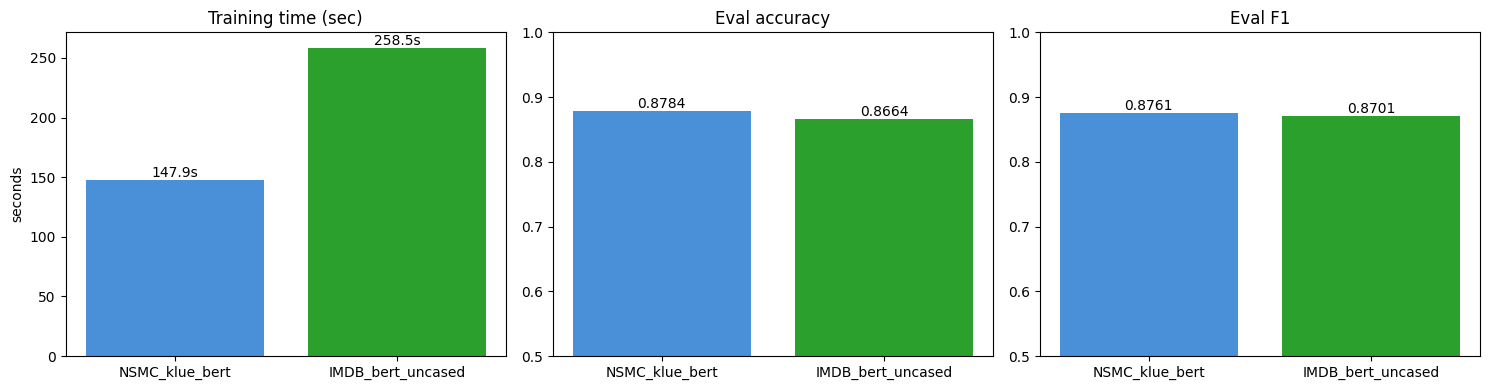

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

cmp_df = pd.DataFrame(comparison_results)
print(cmp_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
names = cmp_df["name"].tolist()
colors = ["#4a90d9", "#2ca02c"]

axes[0].bar(names, cmp_df["train_time_sec"], color=colors)
axes[0].set_title("Training time (sec)"); axes[0].set_ylabel("seconds")
for i, v in enumerate(cmp_df["train_time_sec"]):
    axes[0].text(i, v, f"{v:.1f}s", ha="center", va="bottom")

axes[1].bar(names, cmp_df["eval_accuracy"], color=colors)
axes[1].set_title("Eval accuracy"); axes[1].set_ylim(0.5, 1.0)
for i, v in enumerate(cmp_df["eval_accuracy"]):
    axes[1].text(i, v, f"{v:.4f}", ha="center", va="bottom")

axes[2].bar(names, cmp_df["eval_f1"], color=colors)
axes[2].set_title("Eval F1"); axes[2].set_ylim(0.5, 1.0)
for i, v in enumerate(cmp_df["eval_f1"]):
    axes[2].text(i, v, f"{v:.4f}", ha="center", va="bottom")

plt.tight_layout(); plt.show()

### 7) 결과 해석 가이드

**일반적으로 관찰되는 경향**

1. **두 데이터셋 모두 0.85~0.92 수준의 accuracy/F1을 보입니다.** 동일한 fine-tuning 파이프라인이 언어/모델만 바꿔도 잘 작동함을 보여줍니다.

2. **IMDB의 잘림(truncation) 문제**: IMDB는 평균 토큰 길이가 ~250으로 `max_length=128`을 넘는 샘플이 60% 이상입니다. 즉 IMDB는 리뷰의 앞 128토큰만 보고 분류하는데도 높은 성능이 나오며, 이는 영화 리뷰가 도입부에서 이미 감정 어조를 드러낸다는 점을 시사합니다. `max_length=256`이나 `512`로 늘리면 성능이 더 개선되는 경향이 있어요.

3. **NSMC의 짧은 텍스트 특성**: 평균 ~25토큰의 짧은 댓글이라 정보량이 적고, 구어/은어/오타가 많아 학습이 어려울 수 있습니다. 그럼에도 `klue/bert-base`가 한국어 사전학습을 충분히 했기 때문에 IMDB와 유사한 성능을 냅니다.

4. **학습 시간**: NSMC는 짧은 시퀀스 덕분에 같은 샘플 수라면 IMDB보다 약간 빠르게 학습됩니다(특히 dynamic padding 사용 시).

**주의할 점**
- 두 결과를 "NSMC가 IMDB보다 어렵다/쉽다"고 단정하기 어렵습니다. 모델, 토크나이저, 사전학습 코퍼스가 다르기 때문입니다.
- 더 엄밀한 비교를 원한다면 **다국어 모델**(`bert-base-multilingual-cased`, `xlm-roberta-base`)로 두 데이터셋을 모두 학습해 모델 변수를 통제해야 합니다.

**확장 실험 아이디어**
- `max_length`를 128 → 256 → 512로 늘려가며 IMDB 성능 변화 측정
- epoch을 3~5로 늘려 수렴 후 최종 성능 비교
- 다국어 모델로 cross-lingual zero-shot transfer 테스트 (NSMC로 학습 → IMDB로 평가)